In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

try:

    df = pd.read_csv('Ventas 2023-2025 11-03-26 - CSV.csv', sep=';') # Se añadió 'sep=';''

    print("\n¡Base de datos CSV importada con éxito!")
    print("Primeras 5 filas para ver los datos y campos:\n")
    display(df.head())

    print("\nInformación general (columnas, tipos de datos, valores no nulos):\n")
    df.info()

except FileNotFoundError:
    print("Error: El archivo CSV no se encontró. Asegúrate de que la ruta sea correcta.")
    print("Si el archivo está en tu PC, puedes subirlo a Colab (menú lateral > ícono de carpeta > Subir).")
    print("Si el archivo está en Google Drive, asegúrate de haber montado Google Drive y de que la ruta sea correcta.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo CSV: {e}")


¡Base de datos CSV importada con éxito!
Primeras 5 filas para ver los datos y campos:



,FECHA,AÑO,MES,CLIENTES,CODIGO PRODUCTO,CATEGORIA,SUBCATEGORIA,DEMANDA REAL (Q),PRECIO TOTAL,DESCUENTO,DSC %,SUBTOTAL PRODUCTO ANTES DE IMPUESTOS,IVA TOTAL,IVA %,TOTAL PRODUCTO,COSTO TOTAL,GRUPO CLIENTES,TARIFA FACTURA
0,3/4/2023,2023,ABRIL,CL0026,PR1332,ANTIESTRÉS Y PASATIEMPOS,ROMPECABEZAS,1,"$0,75",$-,0%,"$0,75","$0,09",12%,"$0,84","$0,43",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
1,3/4/2023,2023,ABRIL,CL0026,PR0806,ANTIESTRÉS Y PASATIEMPOS,JUEGOS DE MESA,1,"$0,28",$-,0%,"$0,28","$0,03",12%,"$0,31","$0,18",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
2,4/4/2023,2023,ABRIL,CL0053,PR1119,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,60,"$28,20",$-,0%,"$28,20","$3,38",12%,"$31,58","$14,40",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
3,4/4/2023,2023,ABRIL,CL0040,PR1113,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,12,"$5,64",$-,0%,"$5,64","$0,68",12%,"$6,32","$2,88",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
4,5/4/2023,2023,ABRIL,CL0067,PR0794,ANTIESTRÉS Y PASATIEMPOS,JUEGOS DE MESA,2,"$9,35",$-,0%,"$9,35","$1,12",12%,"$10,47","$5,42",PUBLI EMPRESARIAL,PUBLIEMPRESARIAL



Información general (columnas, tipos de datos, valores no nulos):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68034 entries, 0 to 68033
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   FECHA                                   68034 non-null  object
 1   AÑO                                     68034 non-null  int64 
 2   MES                                     68034 non-null  object
 3   CLIENTES                                68034 non-null  object
 4   CODIGO PRODUCTO                         68034 non-null  object
 5   CATEGORIA                               68034 non-null  object
 6   SUBCATEGORIA                            68034 non-null  object
 7   DEMANDA REAL (Q)                        68034 non-null  int64 
 8    PRECIO TOTAL                           68034 non-null  object
 9    DESCUENTO                              68034 non-null  object
 10  DS

Ahora, convertiremos la columna 'FECHA' al formato de fecha y generaremos el gráfico de la demanda a lo largo del tiempo.

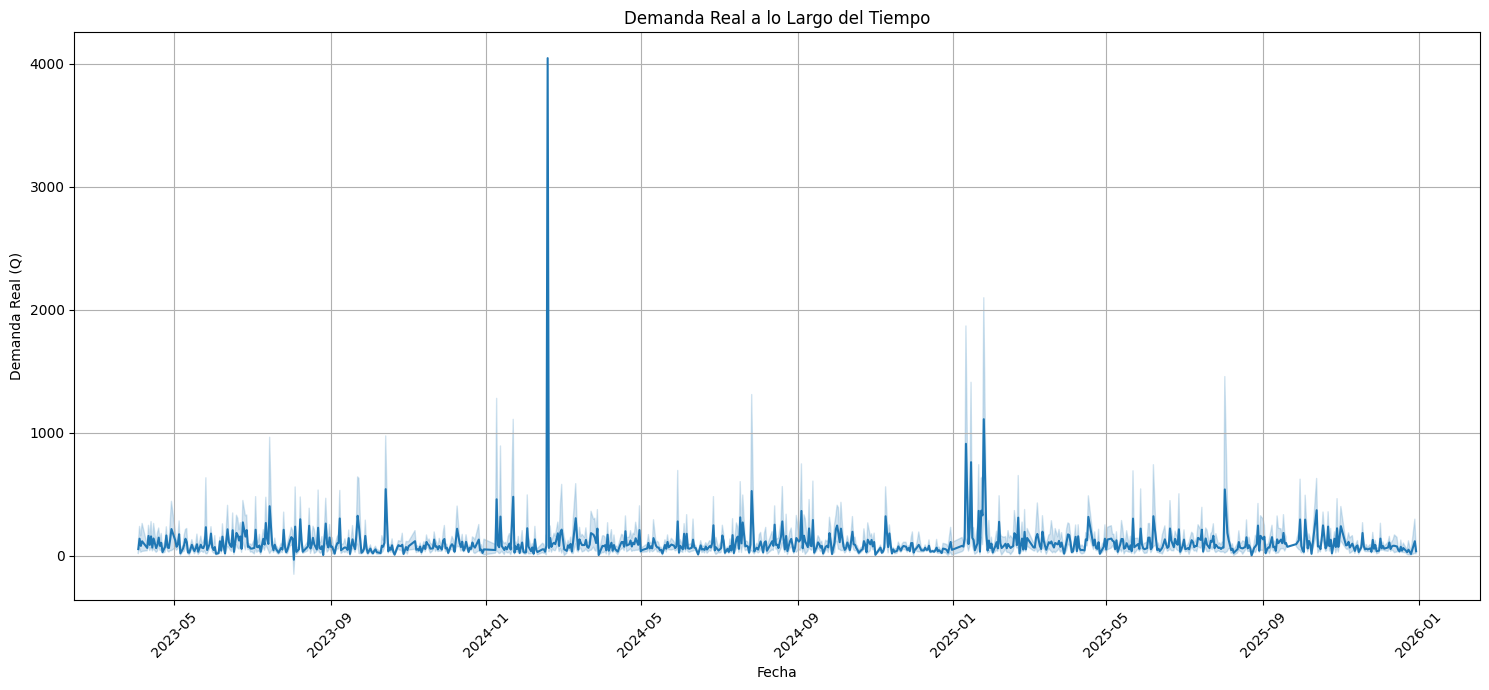

In [6]:
# Asegúrate de que la columna 'FECHA' esté en formato de fecha y hora
# Si tu columna de fecha tiene un formato diferente, es posible que necesites ajustar el argumento 'format'
# Por ejemplo: df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%Y')
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%Y')

# Ordenar los datos por fecha para asegurar una visualización correcta de la serie temporal
df = df.sort_values(by='FECHA')

plt.figure(figsize=(15, 7))
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=df)
plt.title('Demanda Real a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.tight_layout()
plt.show()


In [7]:
# Detectar los datos atípicos utilizando el método del rango intercuartílico (IQR)
Q1 = df['DEMANDA REAL (Q)'].quantile(0.25)
Q3 = df['DEMANDA REAL (Q)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['DEMANDA REAL (Q)'] < lower_bound) | (df['DEMANDA REAL (Q)'] > upper_bound)]

# Eliminar los datos atípicos del DataFrame original
df_cleaned = df[(df['DEMANDA REAL (Q)'] >= lower_bound) & (df['DEMANDA REAL (Q)'] <= upper_bound)]


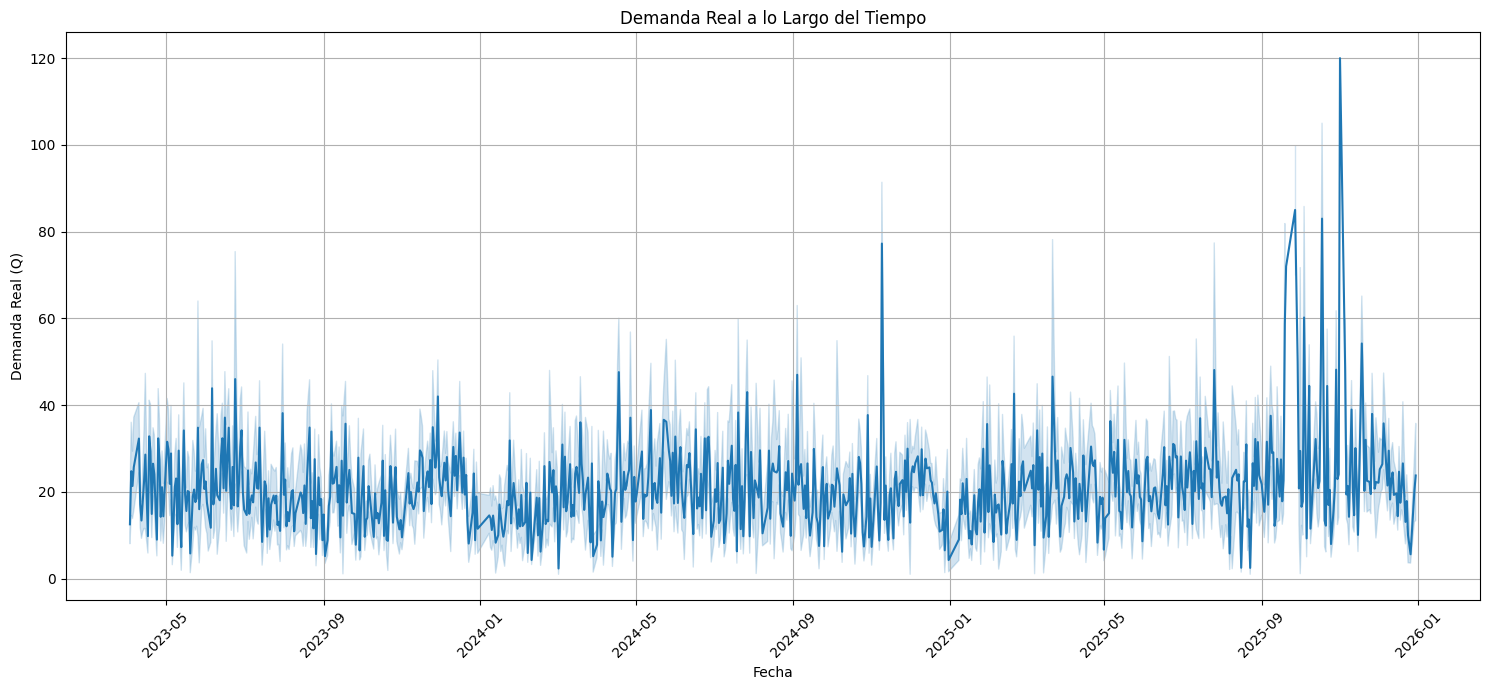

In [8]:

plt.figure(figsize=(15, 7))
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=df_cleaned)
plt.title('Demanda Real a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.tight_layout()
plt.show()

### Segmentación de Datos: Entrenamiento (20%) y Prueba (80%)

Ahora dividiremos nuestro conjunto de datos en dos partes: un conjunto de entrenamiento, que contendrá el 20% de los datos, y un conjunto de prueba, que contendrá el 80% restante. Esto es fundamental para evaluar el rendimiento de cualquier modelo que construyamos, asegurándonos de que no se "sobreajuste" a los datos que ya ha visto.

In [9]:
# Divide la base de datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba) para predicción en tiempo (forecasting temporal)
train_size = int(len(df_cleaned) * 0.8)
train_data = df_cleaned.iloc[:train_size]
test_data = df_cleaned.iloc[train_size:]


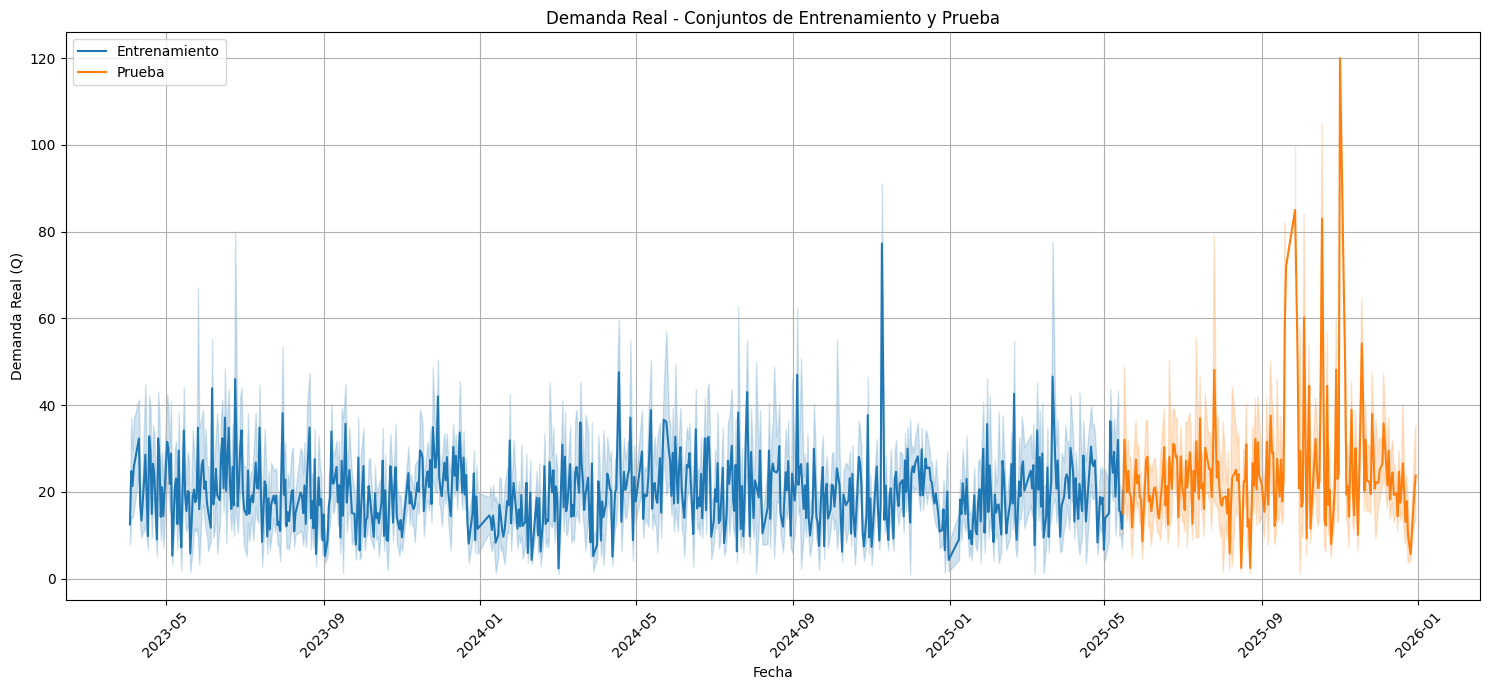

In [10]:
# Plotear los datos de entrenamiento y prueba para visualizar la división
plt.figure(figsize=(15, 7))
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=train_data, label='Entrenamiento')
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=test_data, label='Prueba')
plt.title('Demanda Real - Conjuntos de Entrenamiento y Prueba')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Ajusta un modelo de regresión lineal a los datos de entrenamiento
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Convertir FECHA a valor numérico (ordinal) para la regresión
train_data = train_data.copy()
test_data = test_data.copy()

train_data['FECHA_NUM'] = train_data['FECHA'].map(pd.Timestamp.toordinal)
test_data['FECHA_NUM'] = test_data['FECHA'].map(pd.Timestamp.toordinal)

In [13]:
# Convertir FECHA a valor numérico (ordinal) para la regresión
# Estas líneas se movieron de la celda anterior (6DTh5KcTnLHe) para asegurar que FECHA_NUM exista.
train_data = train_data.copy()
test_data = test_data.copy()

train_data['FECHA_NUM'] = train_data['FECHA'].map(pd.Timestamp.toordinal)
test_data['FECHA_NUM'] = test_data['FECHA'].map(pd.Timestamp.toordinal)

model = LinearRegression()
model.fit(train_data[['FECHA_NUM']], train_data['DEMANDA REAL (Q)'])


LinearRegression()

In [14]:
# Realiza predicciones en el conjunto de prueba
predictions = model.predict(test_data[['FECHA_NUM']])


In [15]:

# Evalúa el rendimiento del modelo
mse = mean_squared_error(test_data['DEMANDA REAL (Q)'], predictions)
r2 = r2_score(test_data['DEMANDA REAL (Q)'], predictions)


In [16]:
import numpy as np
# Evalúa el rmse tomando la raíz cuadrada del mse
rmse = np.sqrt(mse)

In [17]:
# Imprime los resultados de la evaluación
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

Error Cuadrático Medio (MSE): 1050.29
Coeficiente de Determinación (R²): -0.01
Raíz del Error Cuadrático Medio (RMSE): 32.41


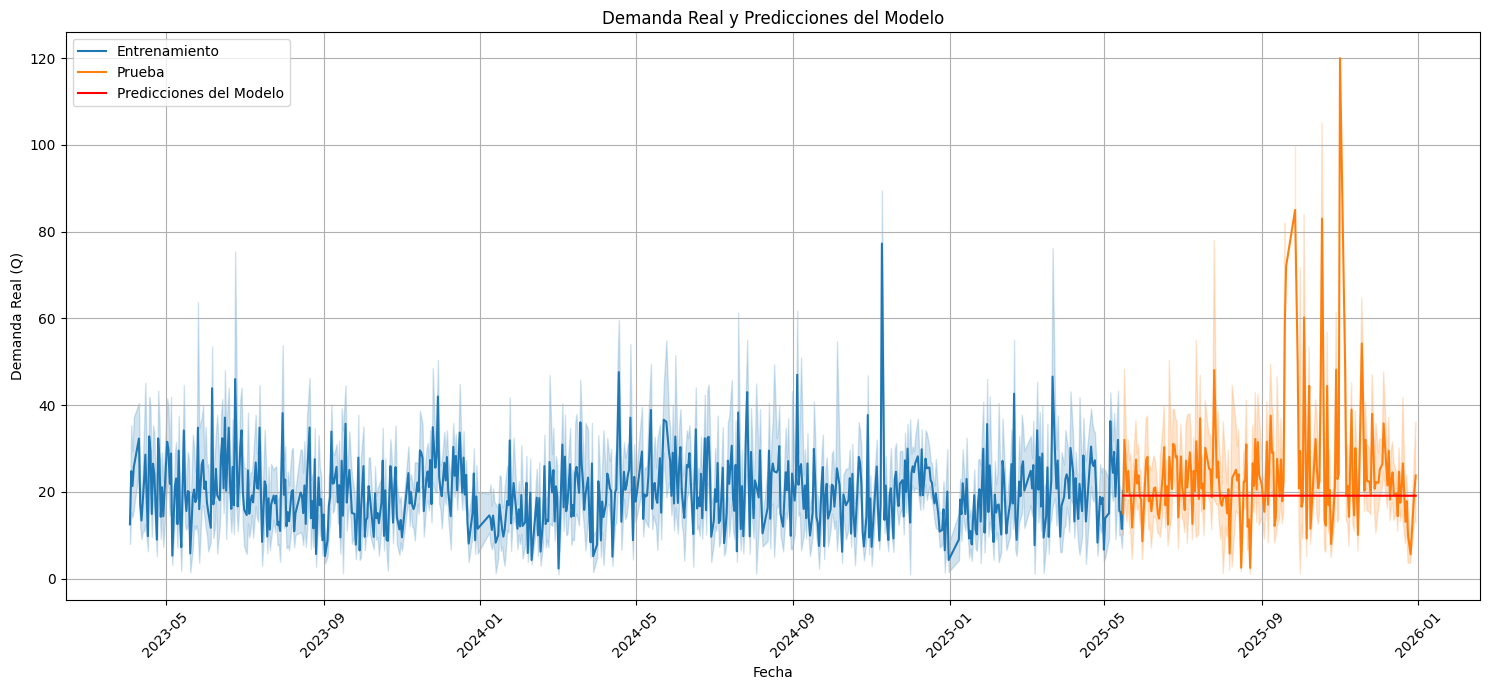

In [18]:
# Grafica la base de datos original, los datos de entrenamiento, los datos de prueba y las predicciones del modelo
plt.figure(figsize=(15, 7))
#sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=df_cleaned, label='Datos Originales')
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=train_data, label='Entrenamiento')
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=test_data, label='Prueba')
sns.lineplot(x=test_data['FECHA'], y=predictions, label='Predicciones del Modelo', color='red')
plt.title('Demanda Real y Predicciones del Modelo')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.legend()
plt.tight_layout()
plt.show()

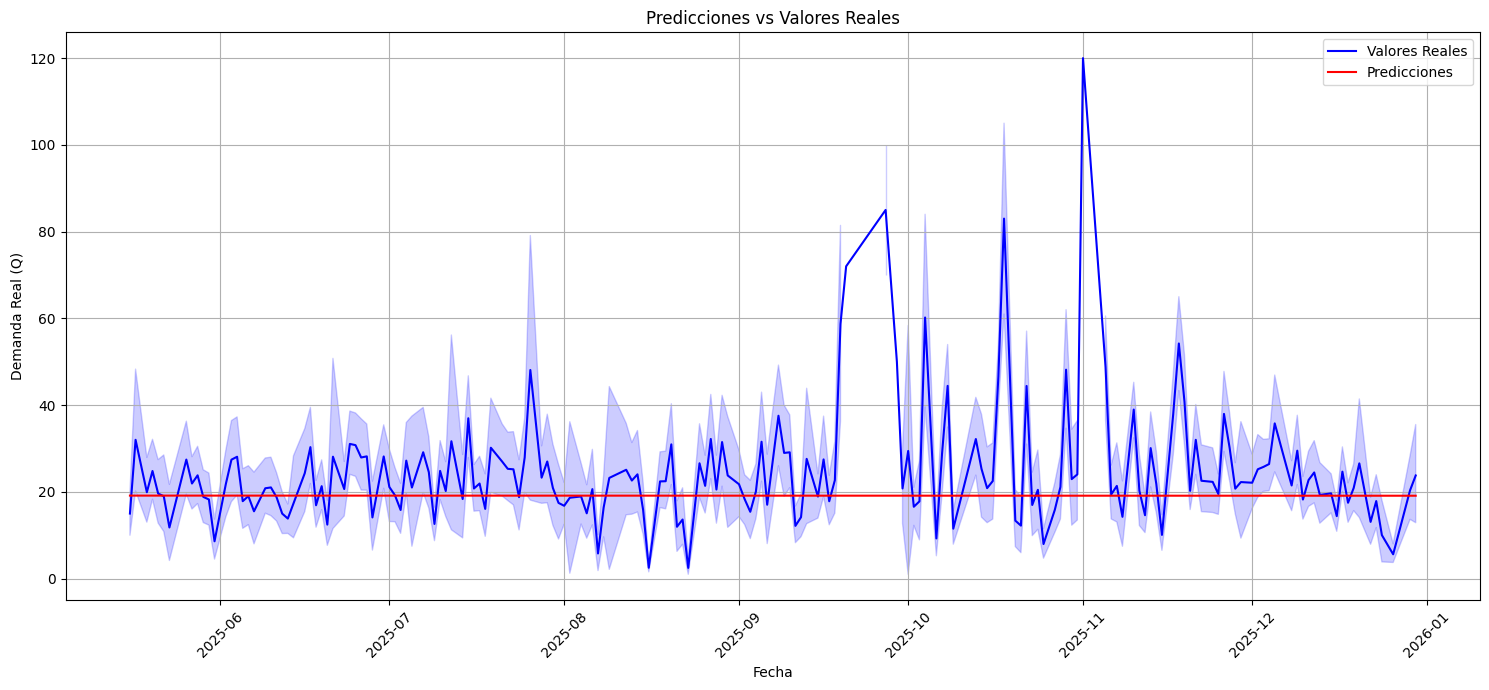

In [19]:

# Grafica las predicciones vs los valores reales
plt.figure(figsize=(15, 7))
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=test_data, label='Valores Reales', color='blue')
plt.plot(test_data['FECHA'], predictions, label='Predicciones', color='red')
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.legend()
plt.tight_layout()
plt.show()

### Predicción de Demanda con el Modelo Holt-Winters

Ahora, aplicaremos un modelo de Suavizado Exponencial de Holt-Winters a nuestros datos de demanda. Este modelo es adecuado para series temporales que presentan tendencias y patrones estacionales. Entrenaremos el modelo con los datos de `train_data` y generaremos predicciones para el período de `test_data`.

In [27]:
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, r2_score

# Establecer la columna 'FECHA' como índice para el modelado de series temporales
train_data_ts = train_data.set_index('FECHA')
test_data_ts = test_data.set_index('FECHA')

# Definir la variable objetivo
y_train = train_data_ts['DEMANDA REAL (Q)']
y_test = test_data_ts['DEMANDA REAL (Q)']

# Ajustar el modelo Holt-Winters
# Se asume una estacionalidad semanal (seasonal_periods=7) y componentes aditivos para la tendencia y la estacionalidad.
# 'initialization_method="estimated"' permite que el modelo estime los valores iniciales.
model_hw = ExponentialSmoothing(
    y_train,
    seasonal_periods=2,  # Asumiendo estacionalidad semanal
    trend='add',         # Tendencia aditiva
    seasonal='add',      # Estacionalidad aditiva
    initialization_method="estimated"
).fit()

# Realizar predicciones en el conjunto de prueba
predictions_hw = model_hw.forecast(len(y_test))

# Evaluar el rendimiento del modelo
mse_hw = mean_squared_error(y_test, predictions_hw)
rmse_hw = np.sqrt(mse_hw)
r2_hw = r2_score(y_test, predictions_hw)

# Imprimir los resultados de la evaluación
print("\n--- Evaluación del Modelo Holt-Winters ---")
print(f"Error Cuadrático Medio (MSE): {mse_hw:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_hw:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_hw:.2f}")


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



--- Evaluación del Modelo Holt-Winters ---
Error Cuadrático Medio (MSE): 1049.94
Coeficiente de Determinación (R²): -0.01
Raíz del Error Cuadrático Medio (RMSE): 32.40


### Visualización de Predicciones del Modelo Holt-Winters

Ahora, visualizaremos las predicciones del modelo Holt-Winters junto con los datos de entrenamiento y prueba para observar cómo se ajusta a la serie temporal.


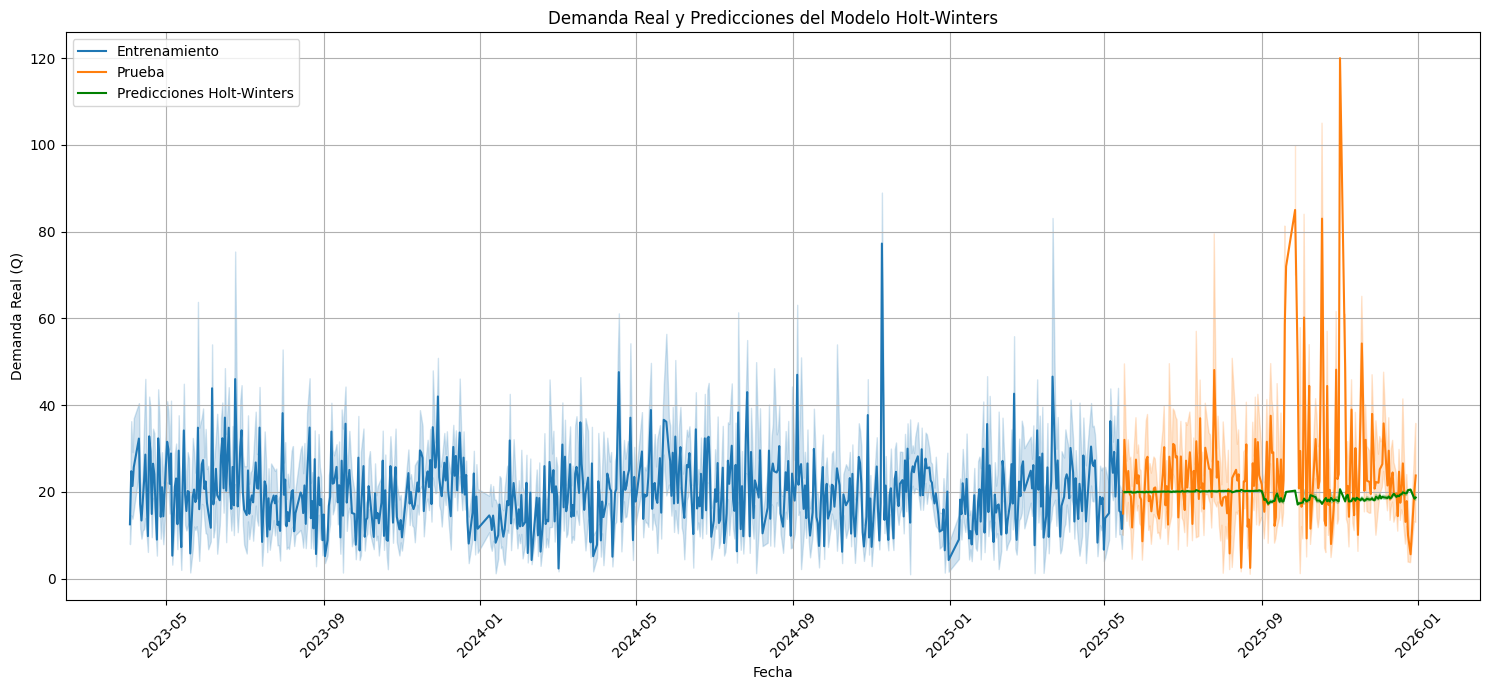

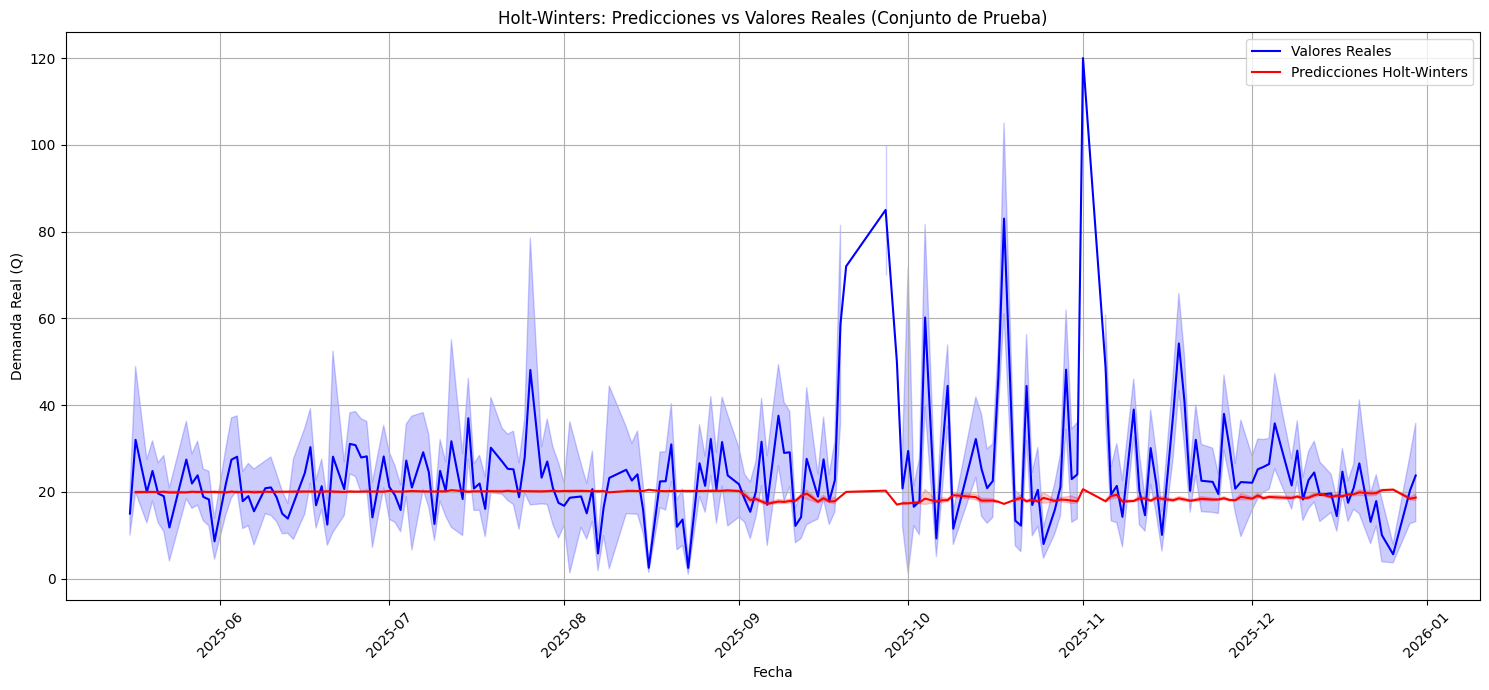

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficar la base de datos original, los datos de entrenamiento, los datos de prueba y las predicciones del modelo Holt-Winters
plt.figure(figsize=(15, 7))
sns.lineplot(x=train_data['FECHA'], y=train_data['DEMANDA REAL (Q)'], label='Entrenamiento')
sns.lineplot(x=test_data['FECHA'], y=test_data['DEMANDA REAL (Q)'], label='Prueba')
sns.lineplot(x=test_data['FECHA'], y=predictions_hw, label='Predicciones Holt-Winters', color='green')
plt.title('Demanda Real y Predicciones del Modelo Holt-Winters')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.legend()
plt.tight_layout()
plt.show()

# Graficar las predicciones vs los valores reales solo para el conjunto de prueba
plt.figure(figsize=(15, 7))
sns.lineplot(x=test_data['FECHA'], y=test_data['DEMANDA REAL (Q)'], label='Valores Reales', color='blue')
sns.lineplot(x=test_data['FECHA'], y=predictions_hw, label='Predicciones Holt-Winters', color='red')
plt.title('Holt-Winters: Predicciones vs Valores Reales (Conjunto de Prueba)')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.legend()
plt.tight_layout()
plt.show()


### Predicción de Demanda con el Modelo LSTM

Ahora implementaremos un modelo de red neuronal de memoria a corto y largo plazo (LSTM) para predecir la demanda. Los modelos LSTM son muy efectivos para capturar patrones temporales complejos en series de tiempo.

In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Preparar Datos para LSTM

# Extraer la serie de demanda de los conjuntos de entrenamiento y prueba
demand_train = train_data['DEMANDA REAL (Q)'].values.reshape(-1, 1)
demand_test = test_data['DEMANDA REAL (Q)'].values.reshape(-1, 1)

# Escalar los datos (ajustar el escalador solo con los datos de entrenamiento para evitar fuga de datos)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(demand_train)
scaled_test = scaler.transform(demand_test)

# Función para crear secuencias para el modelo LSTM
def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Definir el período 'look_back' (cuántos pasos de tiempo anteriores se usarán para predecir el siguiente)
look_back = 7 # Usaremos los datos de los 7 días anteriores

# Crear conjuntos de datos de entrenamiento y prueba con secuencias
X_train_lstm, y_train_lstm = create_dataset(scaled_train, look_back)
X_test_lstm, y_test_lstm = create_dataset(scaled_test, look_back)

# Reformar la entrada para que sea [muestras, pasos de tiempo, características] para LSTM
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

print(f"Dimensiones de X_train_lstm: {X_train_lstm.shape}")
print(f"Dimensiones de y_train_lstm: {y_train_lstm.shape}")
print(f"Dimensiones de X_test_lstm: {X_test_lstm.shape}")
print(f"Dimensiones de y_test_lstm: {y_test_lstm.shape}")


Dimensiones de X_train_lstm: (47666, 7, 1)
Dimensiones de y_train_lstm: (47666,)
Dimensiones de X_test_lstm: (11912, 7, 1)
Dimensiones de y_test_lstm: (11912,)


In [30]:
# 2. Construir el Modelo LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(units=60, return_sequences=False, input_shape=(look_back, 1))) # 1 capa LSTM, 60 unidades
model_lstm.add(Dropout(0.2)) # Dropout de 0.2
model_lstm.add(Dense(1)) # Capa de salida para una única predicción

# Compilar el modelo con el optimizador Adam y una tasa de aprendizaje de 0.001
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Mostrar resumen del modelo
model_lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60)             │        14,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,941 (58.36 KB)

 Trainable params: 14,941 (58.36 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# 3. Entrenar el Modelo LSTM
print("Entrenando el modelo LSTM...")
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=50, # Número de épocas: 50
    batch_size=32, # Tamaño del lote: 32
    verbose=1,
    shuffle=False # Importante para datos de series de tiempo
)
print("Entrenamiento del modelo LSTM completado.")


Entrenando el modelo LSTM...
Epoch 1/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0285
Epoch 2/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0263
Epoch 3/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0260
Epoch 4/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0258
Epoch 5/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0258
Epoch 6/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0257
Epoch 7/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0257
Epoch 8/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0256
Epoch 9/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0256
Epoch 10/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0256
Epoch 11/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0255
Epoch 12/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0255
Epoch 13/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0255
Epoch 14/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0255

In [32]:
# 4. Realizar Predicciones

# Realizar predicciones en el conjunto de entrenamiento y prueba
train_predict_scaled_lstm = model_lstm.predict(X_train_lstm)
test_predict_scaled_lstm = model_lstm.predict(X_test_lstm)

# Invertir la transformación de las predicciones a la escala original
train_predict_lstm = scaler.inverse_transform(train_predict_scaled_lstm)
test_predict_lstm = scaler.inverse_transform(test_predict_scaled_lstm)

# Invertir la transformación de los valores reales para la comparación
y_train_actual_lstm = scaler.inverse_transform(y_train_lstm.reshape(-1, 1))
y_test_actual_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))


1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [33]:
# 5. Evaluar el Rendimiento del Modelo LSTM
mse_lstm = mean_squared_error(y_test_actual_lstm, test_predict_lstm)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_test_actual_lstm, test_predict_lstm)

print("\n--- Evaluación del Modelo LSTM ---")
print(f"Error Cuadrático Medio (MSE): {mse_lstm:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_lstm:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_lstm:.2f}")



--- Evaluación del Modelo LSTM ---
Error Cuadrático Medio (MSE): 950.32
Raíz del Error Cuadrático Medio (RMSE): 30.83
Coeficiente de Determinación (R²): 0.09


### Visualización de Predicciones del Modelo LSTM

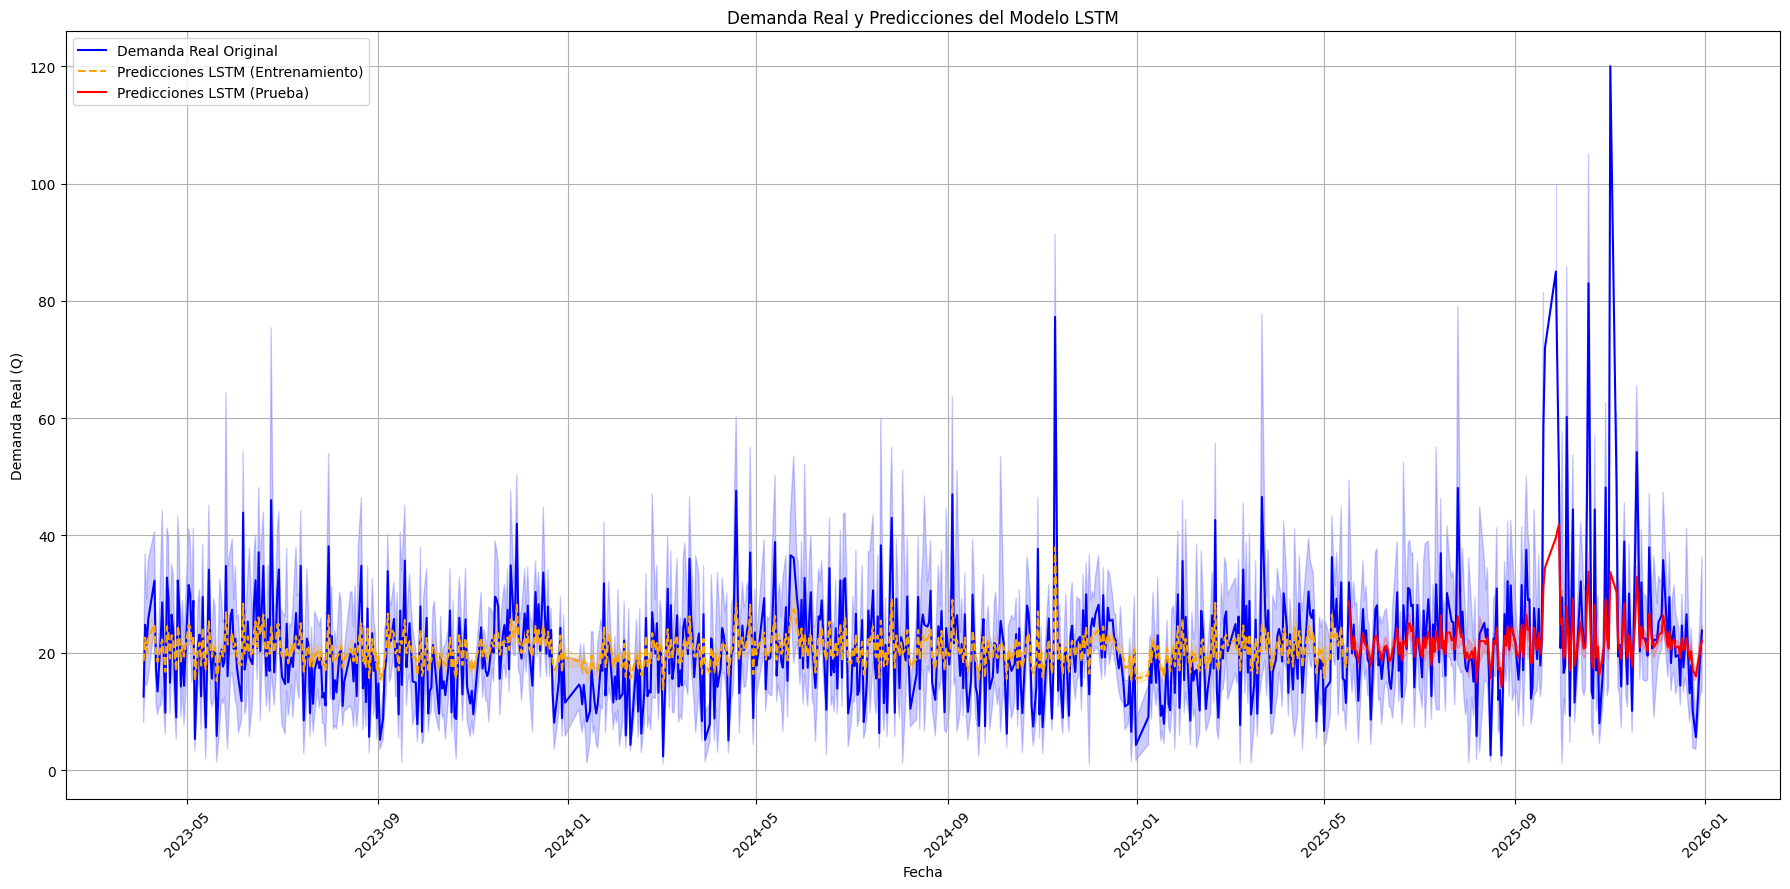

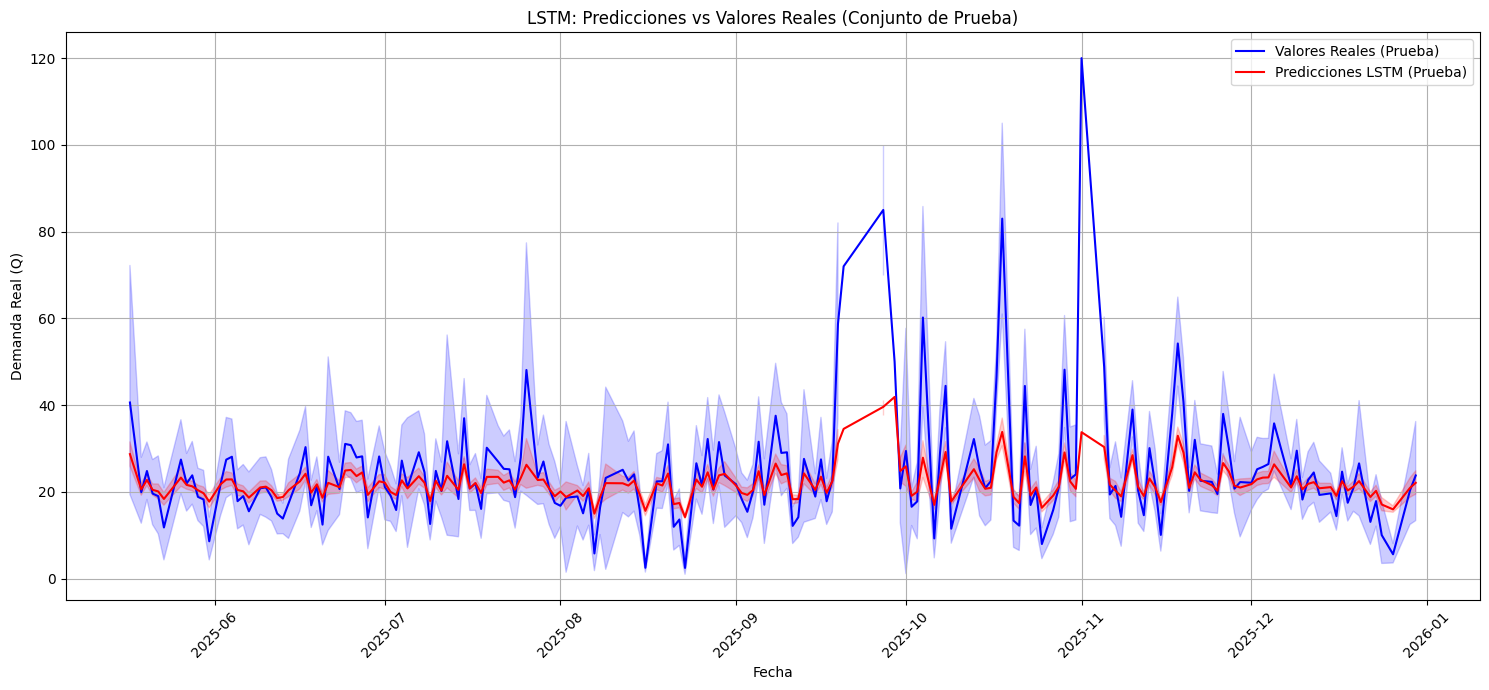

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos para el gráfico combinado
plot_df = df_cleaned.copy()
plot_df['Actual'] = df_cleaned['DEMANDA REAL (Q)']
plot_df['LSTM_Train_Pred'] = np.nan
plot_df['LSTM_Test_Pred'] = np.nan

# Rellenar las predicciones de entrenamiento en el DataFrame combinado
train_pred_start_idx = look_back
train_pred_end_idx = look_back + len(train_predict_lstm)
plot_df.loc[df_cleaned.index[train_pred_start_idx:train_pred_end_idx], 'LSTM_Train_Pred'] = train_predict_lstm.flatten()

# Rellenar las predicciones de prueba en el DataFrame combinado
test_pred_start_idx = len(train_data) + look_back
test_pred_end_idx = len(train_data) + look_back + len(test_predict_lstm)
plot_df.loc[df_cleaned.index[test_pred_start_idx:test_pred_end_idx], 'LSTM_Test_Pred'] = test_predict_lstm.flatten()

# Graficar la Demanda Real y las Predicciones del Modelo LSTM (conjunto completo)
plt.figure(figsize=(18, 9))
sns.lineplot(x=plot_df['FECHA'], y=plot_df['Actual'], label='Demanda Real Original', color='blue')
sns.lineplot(x=plot_df['FECHA'], y=plot_df['LSTM_Train_Pred'], label='Predicciones LSTM (Entrenamiento)', color='orange', linestyle='--')
sns.lineplot(x=plot_df['FECHA'], y=plot_df['LSTM_Test_Pred'], label='Predicciones LSTM (Prueba)', color='red')
plt.title('Demanda Real y Predicciones del Modelo LSTM')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graficar las Predicciones vs Valores Reales (solo conjunto de prueba)
plt.figure(figsize=(15, 7))
sns.lineplot(x=test_data['FECHA'].iloc[look_back:look_back+len(y_test_actual_lstm)], y=y_test_actual_lstm.flatten(), label='Valores Reales (Prueba)', color='blue')
sns.lineplot(x=test_data['FECHA'].iloc[look_back:look_back+len(test_predict_lstm)], y=test_predict_lstm.flatten(), label='Predicciones LSTM (Prueba)', color='red')
plt.title('LSTM: Predicciones vs Valores Reales (Conjunto de Prueba)')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
